In [1]:
import pandas as pd
df = pd.read_csv("monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [2]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


Text(0.5, 1.0, 'Monthly Milk Production')

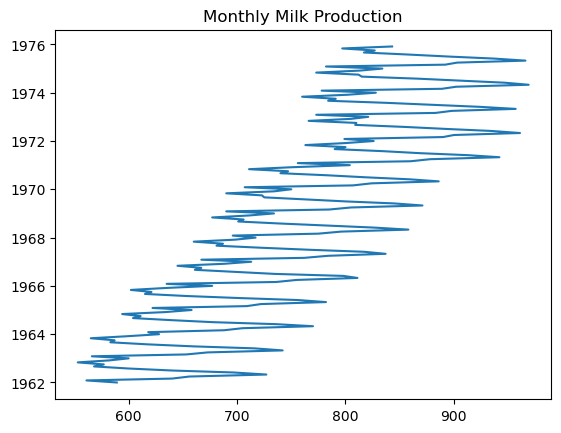

In [5]:
import matplotlib.pyplot as plt

df = pd.read_csv("monthly_milk_production.csv", parse_dates=['Date'], index_col='Production')

plt.plot(df)
plt.title("Monthly Milk Production")

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [7]:
import numpy as np

def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step)])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 12
X, y = create_dataset(scaled_data, time_step)

In [8]:
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [9]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [10]:
!pip install tensorflow

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential([SimpleRNN(50, activation='relu', input_shape=(time_step,1)),Dense(1)])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, y_train, epochs=50, batch_size=16)

C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0636
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0048
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0045
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0012    
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.7454e-04
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.1913e-04 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4852e-04
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.4665e-04
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.2199e-04
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 4.9906e-05
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.5157e-05
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4954e-06
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4485e-06 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.4120e-06
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - l

In [12]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([LSTM(50, activation='relu', input_shape=(time_step,1)),Dense(1)])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=50, batch_size=16)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.2407
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1870
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1419
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0928
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0440
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0094
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0086
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0042
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0041
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0028
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0025 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0019 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.5251e-04
Epoch 16/50
8/8 ━━━━━━━━━━━

In [13]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([GRU(50, activation='relu', input_shape=(time_step,1)),Dense(1)])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train, y_train, epochs=50, batch_size=16)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2465
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1616
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1041
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0609
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0307
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0112
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0086
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0028
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5971e-04
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.1999e-05
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.2106e-05
Epoch 16/50
8/8 ━━━━━━

In [14]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


In [15]:
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, pred_lstm))
mae = mean_absolute_error(y_test_actual, pred_lstm)
mape = np.mean(np.abs((y_test_actual - pred_lstm)/y_test_actual))*100

In [17]:
future_steps = 12
input_seq = X_test[-1]

future_preds = []

for _ in range(future_steps):
    pred = model_lstm.predict(input_seq.reshape(1, time_step, 1))
    future_preds.append(pred[0][0])
    input_seq = np.append(input_seq[1:], pred)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


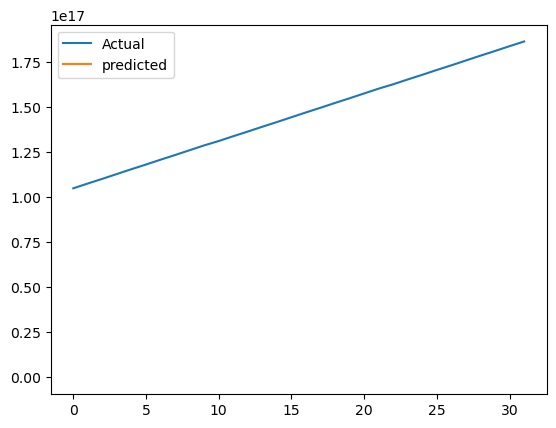

In [18]:
plt.plot(y_test_actual, label="Actual")
plt.plot(pred,label="predicted")
plt.legend()
plt.show()

### BUSINESS INSIGHTS

In [ ]:
* Inventory planning 
* Workforce 
  